<a href="https://colab.research.google.com/github/Mohith200023/AI_Interview_Assist/blob/main/Interview_Prep_7/interview_prep_simulation_scenarios_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building an MCP-Enabled AI Agent: Model Evaluation, Tool Use, and Explainability

Sai Mohith Reddy Vepanjeri

NOT YOUR ID

* https://towardsdatascience.com/the-gap-between-junior-and-senior-data-scientists-isnt-code/
* https://www.freecodecamp.org/news/learn-python-and-build-autonomous-agents/
* https://www.dataannotation.tech/software-developers
* https://python.plainenglish.io/stop-building-toy-projects-beginner-data-science-projects-recruiters-care-about-a26887d2f16d
* https://www.infoq.com/news/2026/02/ai-coding-skill-formation/
* https://finance.yahoo.com/news/mark-cuban-says-software-dead-110021988.html

## Getting Started

* Edit Your Name
* Automatic 0 if you include your student id or any other id
* Name the file Your_Name.ipynb
* Share the link with Anyone with link and Edit privileges

## Context
This week we are focusing on **MCP (Model Context Protocol)** and **Agent Skills**. In this assignment, you will build and evaluate a small AI system that behaves like an agent: it will select and use models as tools, evaluate its own performance, and produce explanations for its decisions.

You are not just training and evaluating a classifier.
You are designing the intelligence layer of an AI agent.

## 1. Introduction

In modern applied AI, models are rarely used in isolation. Real systems require:

- selecting the right model for a given task
- measuring whether it is reliable
- explaining its decisions to stakeholders
- coordinating tools and structured outputs in a repeatable workflow

This project simulates that reality.

You will train multiple candidate models, compare them using evaluation metrics, and then package your conclusions as if you were preparing to deploy an agent that must justify its choices.

## 2. Project Overview

You will complete a full mini-lifecycle of an MCP-enabled agent design:

1. **Define the task and constraints**
   - What is the agent trying to do?
   - What does “good” performance mean in context?

2. **Train candidate models (the agent’s tools)**
   - Multiple models will be trained as alternatives the agent could use.

3. **Evaluate performance**
   - Confusion matrix and classification metrics
   - Precision/recall tradeoffs
   - Underfitting/overfitting and bias/variance discussion

4. **Make the system explainable**
   - Use model interpretability (SHAP/LIME) to explain behavior
   - Identify which features drive decisions

5. **Agent Skills and MCP framing**
   - Structured outputs: consistent, machine-readable results
   - Tool selection logic: which model should the agent choose and why?
   - A clean “agent report” artifact suitable for a technical audience

## 3. Deliverables

You will produce two deliverables:

### A) Working Notebook (Primary Deliverable)
Your notebook must:

- run end-to-end without errors in **Google Colab**
- include code, results, and written interpretation
- include at least one structured summary artifact (JSON-like dict output is acceptable)

### B) Agent Report (Embedded in Notebook)
You will include a final written section titled:

**“Agent Design Decision and Justification”**

It must clearly answer:

- Which model should the agent use?
- Why is it the best choice given the evaluation metrics?
- What are the main failure modes (what does it get wrong)?
- What does SHAP reveal about the model’s behavior?
- What would you do next if this were going into production?

## 4. Time Expectations

This project is split into two parts:

### In-Class Work (2.5 hours)
Goal: get a working baseline and start model comparison.

Expected completion in class:

- problem framing and dataset understanding
- baseline model training
- core evaluation (confusion matrix + metrics)
- at least 2 candidate models trained and compared

### Take-Home Work (3 hours)
Goal: complete deeper analysis and agent framing.

Expected completion at home:

- finish model comparison (additional models and/or tuning)
- interpretability with SHAP
- finalize structured “agent report” section
- polish: clean narrative, clear results, reproducible execution

## 5. Expectations (Graduate Level)

This is a graduate-level assignment. Projects like this are designed to make you stand out in an interview. This is what will hopefully separate you from others that have gone through school doing only what they are told to do.

You are expected to demonstrate:

### Technical correctness
- code runs without errors
- evaluation is computed correctly
- plots are readable and labeled where appropriate
- unit tests

### Analytical depth
- you interpret metrics in context (not just reporting numbers)
- you explain tradeoffs (precision vs recall, bias vs variance)
- you justify your model choice beyond “highest accuracy”

### System thinking (Agent + MCP framing)
- you treat models as tools the agent can choose
- you create a structured summary of results
- you write conclusions suitable for a stakeholder or engineering handoff

### Professional communication
- short, clear written explanations
- correct terminology
- honest discussion of limitations

## 6. Rules and Constraints

- You may use standard libraries available in Colab (scikit-learn, numpy, pandas, matplotlib).
- You may not submit screenshots as a substitute for outputs. Results must be in the notebook.
- You must include written interpretation in each major section.
- If you use any non-standard package, you must install it in the notebook and justify why it is needed.

## 7. Grading Emphasis (What Matters Most)

This assignment is evaluated primarily on:

- correctness and reproducibility
- quality of reasoning and interpretation
- quality of final agent decision and justification
- clarity and professionalism of the notebook narrative

## 8. How to Work During Class

During the in-class portion:

- move sequentially through the sections
- do not aim for perfection early
- prioritize getting a working pipeline + metrics first
- once you have a baseline, then expand to comparisons

If you get stuck:

- isolate the error
- write down what you tried
- ask for help with a specific question (error message + cell number)

## 9. What You Should Be Able to Explain Out Loud (Interview Readiness)

By the end, you should be able to explain anything and everything

### Next: Setup and Data
In the next section you will import libraries, load data, and define the agent’s task and evaluation criteria.

In [1]:
# Setup cell (safe to run in Colab)
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: 3.12.12
NumPy: 2.0.2
Pandas: 2.2.2


## Section 1 — Understanding the Agent’s Task

### MCP Framing: Defining the Agent’s Mission

Before training models or writing code, we must define the **agent’s purpose**.

In modern AI systems, models are tools used by agents to accomplish tasks. The agent must:

- understand its objective
- use data as context
- make predictions
- evaluate whether those predictions are reliable
- communicate results in a structured way

In this assignment, you are designing the **decision-making layer of an AI agent**.

Your first responsibility is to understand:

**What is the agent trying to do?**

### The Scenario

Imagine you are working on an AI agent that assists an organization by making predictions based on structured data.

Each row in your dataset represents:

- one observation
- one situation the agent must evaluate
- one decision the agent must support

Your job is to:

- understand the dataset
- identify the prediction target
- determine what success means for the agent

Only after this step can you select appropriate models.


### Why This Step Matters (Agent Engineering Perspective)

If you do not understand:

- what the agent is predicting
- what errors matter most

then you cannot design a reliable system.

This step defines:

- the agent’s mission
- the agent’s success criteria
- the agent’s risks and limitations

### Your Task in This Section

You will:

1. Load the dataset
2. Inspect its structure
3. Identify the target variable
4. Describe the agent’s objective in plain language
5. Define what success means for the agent

You will answer questions at the end of this section.

In [2]:
# Section 1.1 — Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Section 1.2 — Load Dataset
# We will use a built-in dataset for reliability and reproducibility
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.shape)
print(df.info())
df.head()

(569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Section 1.4 — Target Variable Inspection
print("Target value counts:")
print(df["target"].value_counts())

Target value counts:
target
1    357
0    212
Name: count, dtype: int64


In [5]:
# Section 1.5 — Statistical Summary
df.describe(include='all')

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Section 1 — Questions and Written Responses

Answer the following questions in complete sentences.

#### Question 1

What does each row in this dataset represent?

Explain in plain language.

A) Each row of this data represents one tumor observation from a patient. Numerical measurements of the tumor, which include radius, texture, perimeter, and area, are provided. These measurements will be used to help the agent make a decision regarding whether the tumor is benign or malignant.

#### Question 2

What is the target variable the agent must predict?

A) The Target variable the agent must predict is the tumor diagnosis, meaning whether the tumor belongs to one of the two classes in the breast-cancer dataset.

#### Question 3

What do the values of the target variable mean?

Hint: You may need to look up the breast cancer dataset description.

Explain in plain language.

A) The target variable's classes represent the values of the two diagnosis categories. In other words, the classes imply that the tumor is either benign or malignant. The prediction made by the agent is a classification of a medical nature.


#### Question 4

From an agent perspective, what is the agent’s mission?

Complete this sentence:

A) "The agent’s job is to predict wheather a tumor is benign or malignant based on the measured features of that tumor."

#### Question 5

Which type of error is more dangerous:

False Positive  
or  
False Negative  

Explain your reasoning.

There is no single correct answer — justification matters.

A) The more serious of the two errors for a task of this nature would typically be the false negative. This is because a false negative indicates that the model believes a dangerous condition to be safe, and so could lead to a lack of treatment or other medical intervention. While a false positive is bad and could lead to stress, in the context of a medical screening, the consequences of failing to notice a problem would typically be worse than noticing a problem unnecessarily. False positive and false negative are part of the basic concepts of classification for the purpose of the assignment.

#### Question 6

Why is accuracy alone not always a sufficient metric for evaluating an agent?

#### MCP / Agent Reflection Question

In a real MCP-enabled system, the model is a tool used by the agent.

Why is it important for the agent designer (you) to understand the dataset before selecting tools?

A) Accuracy, on the other hand, is not enough on its own because it’s possible for the model to be doing well in general, yet still be making the wrong kind of errors. This means that precision, recall, and the confusion matrix are also required. For instance, the model could be doing well in general, yet still be failing too many of the really important positive cases.


### Checkpoint

Before moving to Section 2, you should now understand:

- what the agent is predicting
- what the dataset represents
- what success means
- why evaluation criteria matter

In the next section, you will begin training candidate models that the agent can use.

## Section 2 — Training Candidate Models for the Agent

### MCP Framing: Models Are Tools the Agent Can Use

In an MCP-enabled system, an agent does not have only one model. It has access to **multiple candidate tools** and must determine which tool is most reliable for its task.

Each model you train in this section represents:

**a tool the agent could choose to use**

Your responsibility as the agent designer is to:

- train multiple candidate models
- ensure they are trained correctly
- prepare them for evaluation in the next section

You are not deciding the winner yet.

You are building the agent’s toolbox.

### What's the Difference Between MCP Tools and API Calls

* https://www.freecodecamp.org/news/mcp-vs-apis-whats-the-real-difference/

### Why Multiple Models?

Different models learn patterns differently:

- Some are simple and fast
- Some are flexible but risk overfitting
- Some perform better depending on the structure of the data

The agent must eventually select the best tool based on evidence.

### Models You Will Train in This Section

You will train:

* Model 1: Logistic Regression  
* Model 2: K-Nearest Neighbors (KNN)

These represent two fundamentally different learning strategies:

* Logistic Regression → linear decision boundary  
* KNN → distance-based decision making


### Why is Logistic Regression (a Classifier) a Learning Decision Boundary Learning Strategy? What is Linear About Logistic Regression?

Answer Here:

A) Logistic Regression learns a decision boundary because it is aiming to separate the classes based on a mathematical condition based on the input features. What is linear about Logistic Regression is the weighted linear combination of the features before it is eventually converted to a probability. It is building a straight-line or flat-boundary style separation on the feature space, which is why it is called a linear decision boundary classification algorithm.

### Important: Train/Test Split

We must simulate the real world.

The agent trains on past data and makes predictions on new, unseen data.

We accomplish this using a:

Training Set → used to train models  
Test Set → used to evaluate models

The test set must NEVER be used during training.

### Your Task in This Section

You will:

1. Split the dataset into training and test sets
2. Train Logistic Regression
3. Train KNN
4. Generate predictions from both models

Do NOT evaluate performance yet.

That happens in Section 3.

In [6]:
# Section 2.1 — Import Required Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

print("Libraries loaded.")

Libraries loaded.


In [7]:
# Section 2.2 — Define Features and Target
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [8]:
# Section 2.3 — Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 455
Test samples: 114


In [9]:
# Section 2.4 — Train Logistic Regression
log_model = LogisticRegression(max_iter=10000)
log_model.fit(X_train, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [10]:
# Section 2.5 — Train K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("KNN training complete.")

KNN training complete.


In [11]:
# Section 2.6 — Generate Predictions
log_predictions = log_model.predict(X_test)
knn_predictions = knn_model.predict(X_test)

print("Predictions generated.")

Predictions generated.


In [12]:
# Preview Predictions
print("Logistic Regression Predictions:")
print(log_predictions[:10])
print("\nKNN Predictions:")
print(knn_predictions[:10])

Logistic Regression Predictions:
[0 1 0 1 0 1 1 0 0 0]

KNN Predictions:
[0 1 0 0 0 1 1 0 0 0]


### Section 2 — Questions and Written Responses

Answer the following:


### Question 1

In your own words, why did we split the dataset into training and test sets?

A) The data is split into a set used to train the models and a set used to test them. This is to allow the models to learn from one set and then be tested using a different set that they have not been exposed to. This will help us determine how well the models will perform instead of how well they memorize.


### Question 2

Why is it important that the test set is not used during training?

What would happen if it was?

A) The test set should not be used in the training process. This is because the purpose of the test set is to give an unbiased evaluation of the performance of the model. However, when the test set is included in the training process, the agent is likely to choose a tool that appears good but is only good because it has already seen the answers.


### Question 3

From an agent perspective:

Why is it useful for the agent to have multiple models available instead of only one?

A) From an agent point of view, it is good to have multiple models available because it allows it to compare them instead of trusting one. The multiple models will be able to perform differently when given a task to accomplish, and it will be beneficial to have more than one tool available.


### Question 4

Logistic Regression and KNN learn differently.

One learns a mathematical equation.

One compares distance to neighbors.

Why might this lead to different performance?

A) The two models might behave differently because of the different learning patterns used by the models. The first model uses a global mathematical equation to make decisions, while the second model uses similarity to other points to make decisions. The models use different decision patterns because one is an equation-based model and the other is a distance-based model.


### MCP / Agent Reflection Question

Right now, the agent has two tools available:

Logistic Regression  
KNN  

But the agent does not yet know which tool is better.

What evidence will the agent need in order to make that decision?

A) The agent also requires evidence such as the confusion matrix, accuracy, precision, and recall to make a decision on which tool is better. The agent should also take into consideration what types of mistakes both models make, not just how many they got right.


### Checkpoint

At this point, you have successfully:

- trained two candidate models
- generated predictions
- prepared the agent’s toolbox

In the next section, you will evaluate how well each tool performs.

## Section 3 — Evaluating Agent Performance

### MCP Framing: How Does the Agent Know if a Tool is Reliable?

The agent now has access to two tools:

- Logistic Regression
- K-Nearest Neighbors

Both tools produce predictions.

But the agent cannot use a tool blindly.

The agent must evaluate:

**How reliable is each tool?**

This is called **performance evaluation**.

### Why Evaluation Matters

In real AI systems, incorrect predictions have consequences.

The agent designer must understand:

- What kinds of errors occur
- How often they occur
- Whether those errors are acceptable

Not all errors are equally dangerous.

### Confusion Matrix — The Foundation of Evaluation

The confusion matrix breaks predictions into four categories:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

These four values allow us to compute all major performance metrics.

We will compute this for both models.

In [13]:
# Section 3.1 — Import Evaluation Tools
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("Evaluation tools loaded.")

Evaluation tools loaded.


Logistic Regression Confusion Matrix:
[[39  3]
 [ 1 71]]


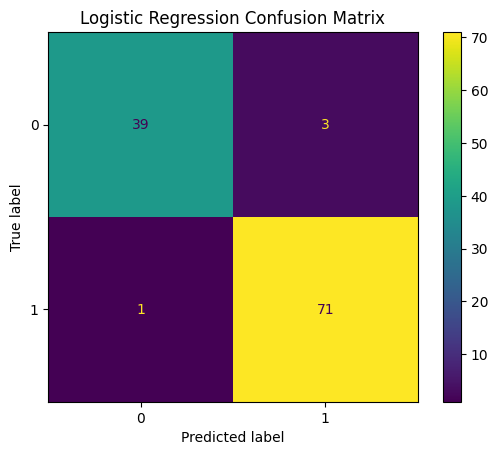

In [14]:
# Section 3.2 — Confusion Matrix: Logistic Regression
log_cm = confusion_matrix(y_test, log_predictions)

print("Logistic Regression Confusion Matrix:")
print(log_cm)

# Visualize Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, log_predictions)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


KNN Confusion Matrix:
[[38  4]
 [ 6 66]]


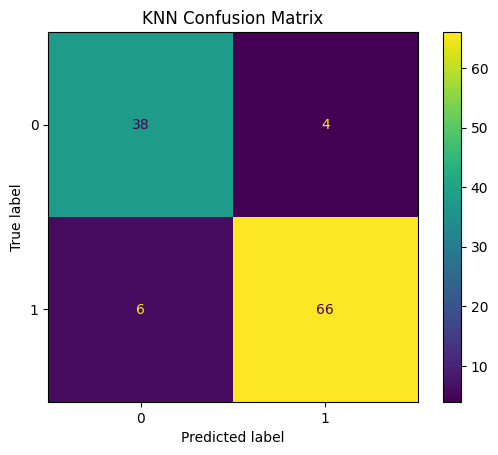

In [15]:
# Section 3.3 — Confusion Matrix: KNN
knn_cm = confusion_matrix(y_test, knn_predictions)

print("KNN Confusion Matrix:")
print(knn_cm)

# Visualize KNN Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, knn_predictions)
plt.title("KNN Confusion Matrix")
plt.show()


### Accuracy — Overall Correctness

Accuracy answers:

"What percentage of predictions were correct?"

Formula:

Accuracy = (TP + TN) / Total

We will compute accuracy for both models.

In [16]:
# Section 3.4 — Accuracy
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, log_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print("Logistic Regression Accuracy:", log_accuracy)
print("KNN Accuracy:", knn_accuracy)

Logistic Regression Accuracy: 0.9649122807017544
KNN Accuracy: 0.9122807017543859


### Precision and Recall — Understanding Error Types

Accuracy alone is not enough.

We also need:

Precision  
Recall  

These help the agent understand:

How trustworthy positive predictions are  
How many real positive cases were detected  


In [17]:
# Section 3.5 — Precision and Recall
from sklearn.metrics import precision_score, recall_score

log_precision = precision_score(y_test, log_predictions)
log_recall = recall_score(y_test, log_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)


print("Logistic Regression Precision:", log_precision)
print("Logistic Regression Recall:", log_recall)

print()
print("KNN Precision:", knn_precision)
print("KNN Recall:", knn_recall)

Logistic Regression Precision: 0.9594594594594594
Logistic Regression Recall: 0.9861111111111112

KNN Precision: 0.9428571428571428
KNN Recall: 0.9166666666666666


### Full Classification Report

This provides a complete summary.

In [18]:
# Section 3.6 — Classification Report
from sklearn.metrics import classification_report

print("Logistic Regression Report:")
print(classification_report(y_test, log_predictions))

print("KNN Report:")
print(classification_report(y_test, knn_predictions))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

KNN Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        42
           1       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



### Section 3 — Questions and Written Responses

Answer the following questions.

#### Question 1 — Confusion Matrix Interpretation

Look at the Logistic Regression confusion matrix.

How many False Positives occurred?

How many False Negatives occurred?

Explain what each means in plain language.

A) In the case of Logistic Regression, there were 3 false positives and 1 false negative. False positives occur when the model classifies the data as positive when in reality the data belongs to the negative class. False negatives occur when the model classifies the data as negative when in reality the data belongs to the positive class.


#### Question 2 — Accuracy Comparison

Which model had higher accuracy?

Is the difference large or small?

A) Logistic Regression had a higher accuracy. The accuracy of Logistic Regression was 0.9649, while that of KNN was 0.9123. It is not a marginal difference. Logistic Regression was correct more often.

#### Question 3 — Precision Interpretation

Which model had higher precision?

What does higher precision mean for the agent?

A) Logistic Regression had a higher precision. This is because a higher precision means that when the agent predicts a positive class, it is more likely to be correct.

#### Question 4 — Recall Interpretation

Which model had higher recall?

What does higher recall mean?

A) Also, the recall of Logistic Regression was higher. A higher recall rate means that the model is able to locate the actual positive data points and miss fewer of them. In the project, a higher recall rate is particularly important since Logistic Regression had only 1 false negative compared to 6 from KNN.

#### Question 5 — Why Accuracy Alone is Not Enough

Imagine a model that predicts every case as the majority class.

Why could accuracy still appear high?

Why would this be dangerous?

A) A model that always predicts the majority class might have a high accuracy rate because one class is significantly larger than the other. This is not good because the model might be totally ignoring the other class and appear to be doing a good job on paper, yet failing to spot those other cases. That is why the confusion matrix, precision, and recall are important.

#### Question 6 — Agent Reliability Decision

Based on:

accuracy  
precision  
recall  

Which model appears more reliable so far?

You do NOT need to make a final decision yet.

Just explain your reasoning.

A) So far, Logistic Regression appears more reliable. It has better accuracy, better precision, and better recall, and it makes fewer total mistakes than KNN. Most importantly, it misses fewer important positive cases, which makes it a stronger candidate for the agent to trust.

#### MCP / Agent Reflection Question

The agent is trying to decide which tool to trust.

Why is it dangerous for the agent to choose a tool based only on accuracy?

A) It is not safe for the agent to choose a tool solely on the basis of its accuracy because it does not indicate the type of errors that the model is making. It is important to understand error patterns, particularly false positives and false negatives, before trusting a tool.

### Checkpoint

At this point, you have:

- computed confusion matrices
- computed accuracy
- computed precision and recall
- interpreted model behavior

You now have evidence the agent can use.

In the next section, you will formally select the best model for the agent.

## Section 4 — Selecting the Best Model for the Agent

### MCP Framing: The Agent Must Choose Its Tool

The agent now has evidence about two candidate tools:

- Logistic Regression
- K-Nearest Neighbors

You have computed:

- confusion matrices
- accuracy
- precision
- recall

The agent’s next responsibility is to make a decision:

**Which tool should the agent use?**

This is called **tool selection**.

### Why Tool Selection Matters

In MCP-enabled systems:

- models are tools
- agents must select tools intentionally
- agents must justify their decisions
- agents must communicate decisions in a structured way

This prevents:

- blind trust in models  
- unjustified deployment  
- unreliable system behavior  


### Important: There Is No Automatic Answer

The model with the highest accuracy is not always the best choice.

You must consider:

- precision
- recall
- types of errors
- reliability

This is an engineering decision.

### Your Role Now

You are acting as the **agent designer**.

You must:

- compare model performance
- select the best model
- justify your reasoning
- produce a structured agent decision report

This structured output simulates how real agents communicate decisions.

In [19]:
# Section 4.1 — Compare Metrics Side-by-Side
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [log_accuracy, knn_accuracy],
    "Precision": [log_precision, knn_precision],
    "Recall": [log_recall, knn_recall]
})

comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.964912,0.959459,0.986111
1,KNN,0.912281,0.942857,0.916667


### Agent Structured Decision Output

In MCP systems, agents produce structured outputs.

This allows:

- other systems to read the result
- decisions to be logged
- tools to be selected automatically

You will now simulate this.

In [20]:
# Section 4.2 — Agent Decision Logic
# Select best model based on accuracy (initial simple rule)

if log_accuracy > knn_accuracy:

    selected_model_name = "Logistic Regression"
    selected_model = log_model
    selected_accuracy = log_accuracy
    selected_precision = log_precision
    selected_recall = log_recall

else:

    selected_model_name = "KNN"
    selected_model = knn_model
    selected_accuracy = knn_accuracy
    selected_precision = knn_precision
    selected_recall = knn_recall


agent_decision = {
    "selected_model": selected_model_name,
    "accuracy": selected_accuracy,
    "precision": selected_precision,
    "recall": selected_recall,
    "status": "candidate_selected"
}

agent_decision

{'selected_model': 'Logistic Regression',
 'accuracy': 0.9649122807017544,
 'precision': 0.9594594594594594,
 'recall': 0.9861111111111112,
 'status': 'candidate_selected'}

### Why Structured Output Matters

This dictionary represents a simplified example of **agent communication**.

In real MCP systems, this output could be:

- sent to another service
- logged in a database
- used to trigger other tools

Structured output is a core Agent Skill.

### Section 4 — Questions and Written Responses

Answer the following:

#### Question 1 — Model Selection

Which model did the agent select?

A) The agent selected Logistic Regression

#### Question 2 — Metric Justification

Was this decision based only on accuracy?

Should precision and recall also influence the decision?

Explain.

A) No, the decision was not based solely on accuracy. Precision and recall should also affect the decision, as they measure how well the model is able to detect important cases and how confident you can be in the predictions it makes. In the current project, the formal rule is to prioritize recall, then precision, then accuracy.

#### Question 3 — Error Risk

Look at the confusion matrix for the selected model.

What type of error still occurs?

Why is this important?

A) The selected model also has false positives and false negatives. In the case of the Logistic Regression model, there are 3 false positives and 1 false negative. This is important because even the best models are not perfect and there is always room for danger in a real-world system.


#### Question 4 — Engineering Judgment

Do you personally agree with the agent’s selection?

If yes, explain why.

If no, explain which model you would choose and why.

You may disagree with the simple accuracy-based selection rule.

A) Yes, I agree with the choice made by the agent. This is because, for the project, Logistic Regression is a better choice than the other two algorithms, given that it has the highest recall, the highest precision, the highest accuracy, and the least number of mistakes. This is because the project aims at detecting actual positive samples, so it has a much lower false negative count than the others.

#### Question 5 — Structured Output Purpose

Why is it useful for the agent to produce its decision in a structured format instead of plain text?

A) It is beneficial to the agent to provide the decision in a structured form because it can then be automatically read, logged, and later used in subsequent steps of the workflow by other systems. It makes the choice of tool repeatable, traceable, and easier to integrate into a larger system.

#### MCP / Agent Reflection Question

In a real MCP system, the agent might have access to dozens of tools.

Why is tool selection a critical responsibility of the agent?

A) The selection of tools is a key task because an agent has a number of tools to choose from, and if a wrong tool is used, it can lead to a decrease in accuracy or a decision that is not reliable. The agent has to evaluate evidence to justify why a particular tool is more reliable than others.



### Checkpoint

You have now:

- trained multiple models
- evaluated their performance
- selected a candidate tool
- produced structured agent output

You have successfully simulated a core agent skill.

### Next Section Preview (Take-Home)

In the next section, you will go deeper.

You will make the agent explain **why** it makes its decisions using SHAP.

This allows the agent to move from:

prediction → explanation

This is a critical capability in modern AI systems.

## This Completes the In-Class Section of This Activity

Please go and enjoy the night. Let me see your work before you go. You are dismissed.

## Section 5 — Making the Agent Explainable (SHAP)

### MCP Framing: The Agent Must Explain Its Decisions

So far, your agent can:

- train tools (models)
- evaluate tools
- select a tool
- produce structured output

But one critical capability is still missing:

**explanation**

In modern AI systems, it is not enough for an agent to say:

"Here is my prediction."

The agent must also answer:

**"Why?"**

This is called **explainability** or **interpretability**.

### Why Explainability Matters

Explainability allows:

- engineers to trust the system
- stakeholders to understand decisions
- errors to be diagnosed
- models to be improved

Without explainability, the agent becomes a **black box**.

MCP-enabled agents must support transparent reasoning.

### SHAP — Shapley Additive Explanations

SHAP is a method that explains:

**how each feature contributes to a prediction**

SHAP assigns each feature a contribution value.

This tells the agent:

- which features increase the prediction
- which features decrease the prediction
- which features matter most overall


### Two Types of Explanation You Will Generate

Global Explanation  
→ How the model behaves overall

Local Explanation  
→ Why the model made a specific prediction

### Your Task in This Section

You will:

- install and import SHAP
- generate SHAP values
- visualize feature importance
- interpret what the agent has learned

This gives your agent **introspection capability**.

In [21]:
# Section 5.1 — Install SHAP (Colab only)
!pip install shap

In [22]:
# Section 5.2 — Import SHAP
import shap

shap.initjs()

print("SHAP loaded.")

SHAP loaded.


In [23]:
# Section 5.3 — Create Explainer
# We will explain the model the agent selected

explainer = shap.Explainer(selected_model, X_train)
shap_values = explainer(X_test)

### Global Explanation — Feature Importance

This plot shows:

Which features matter most overall.

The most important features appear at the top.


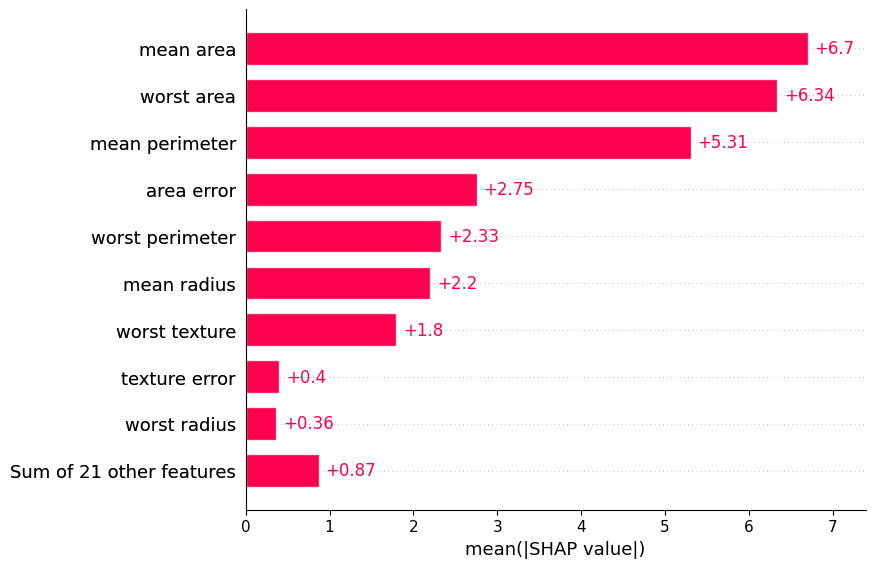

In [24]:
# Section 5.4 — Global Feature Importance Plot
shap.plots.bar(shap_values)

### Summary Plot — Feature Effects

This plot shows:

How features influence predictions.

Each dot represents one observation.

Color represents feature value:

* Red → high value  
* Blue → low value  

Position represents impact on prediction.


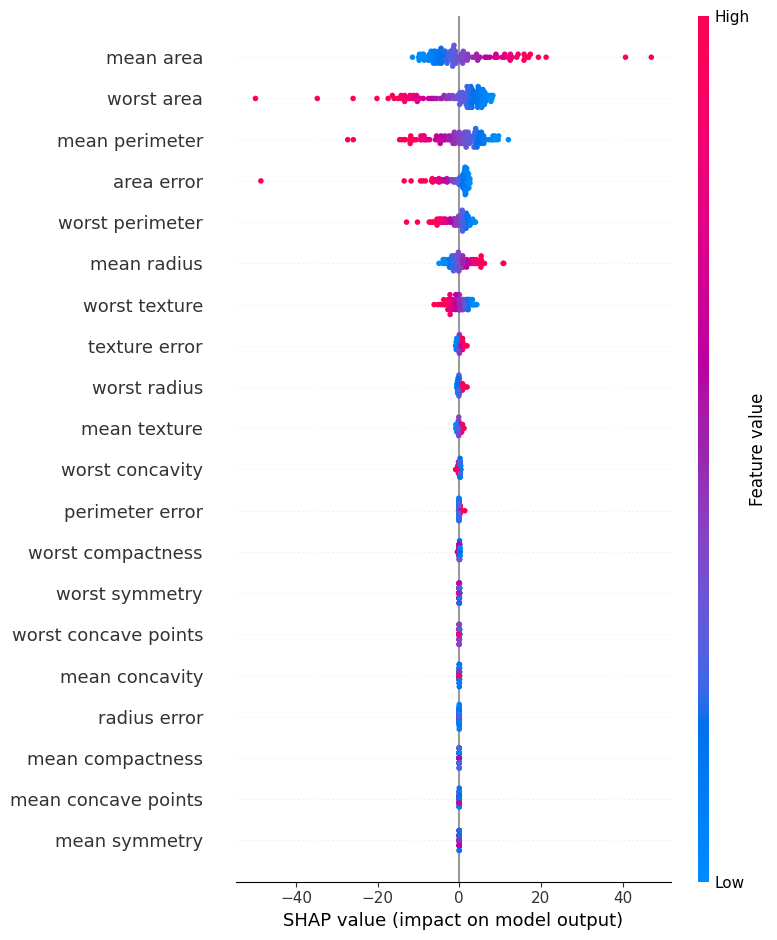

In [25]:
# Section 5.5 — SHAP Summary Plot
shap.summary_plot(shap_values, X_test)

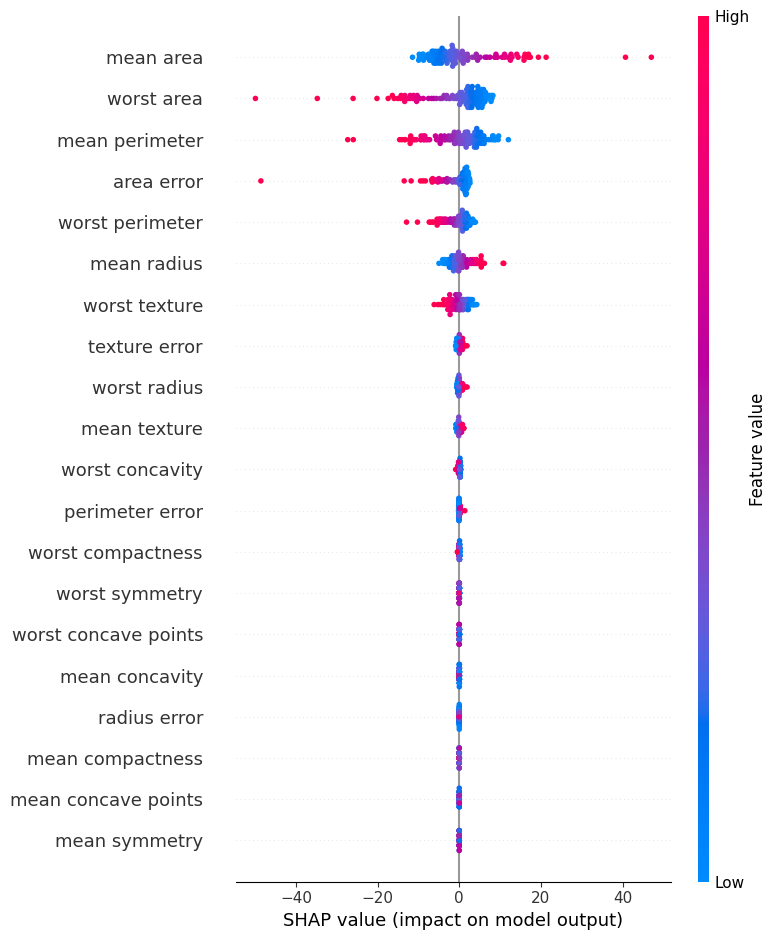

In [26]:
# Section 5.5 — SHAP Summary Plot
shap.summary_plot(shap_values, X_test)

### Local Explanation — Individual Prediction

Now we will explain a single prediction.

This shows exactly why the agent made that decision.

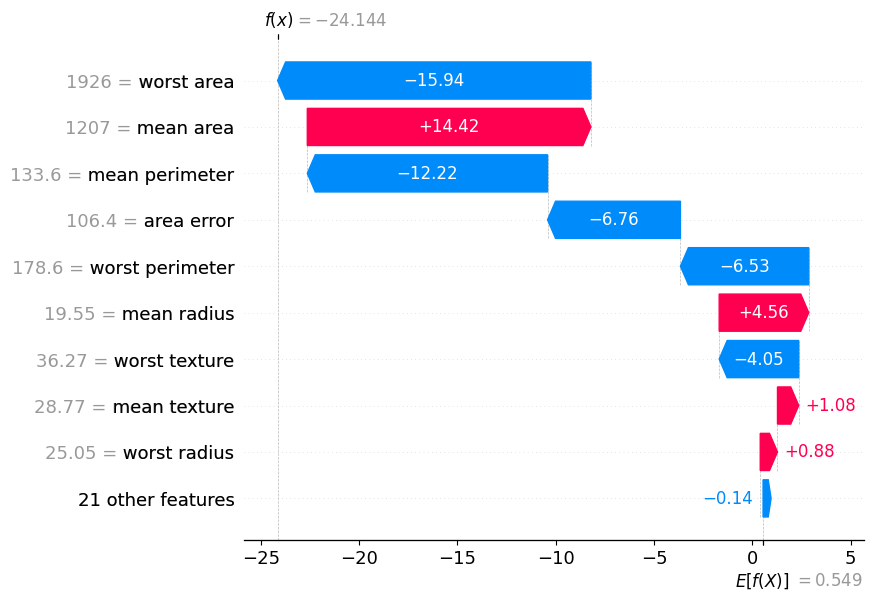

In [27]:
# Section 5.6 — Local Explanation
shap.plots.waterfall(shap_values[0])

### Section 5 — Questions and Written Responses

Answer the following questions.

#### Question 1 — Feature Importance

Which features appear most important?

List at least two.

A) The most important features include mean area and worst area. The explanation also suggests that area- and perimeter-related features are especially influential overall


#### Question 2 — Interpretation

What does it mean for a feature to have high SHAP importance?

Explain in plain language.

A) If a feature has high SHAP importance, it implies that the feature has a high impact on the model’s predictions. In other words, the model is more “attentive” to the feature because it has a significant impact on the model’s prediction.

#### Question 3 — Positive vs Negative Impact

In the summary plot:

* Some features push predictions higher  
* Some push predictions lower  

What does this mean?

A) This means that some of the features increase the probability of the class in the prediction, while the rest decrease the probability of the class in the prediction. The positive values of SHAP increase the probability of class 1 in the prediction, while the negative values decrease the probability of class 0 in the prediction.


#### Question 4 — Local Explanation

Look at the waterfall plot.

Why did the agent make that specific prediction?

Which features influenced it most?

A) In the case of the example, the agent was able to make its prediction because of the strong contributions of some features. The worst area feature was contributing very strongly to class 1, while the mean area feature was contributing very strongly away from class 1, and several other features contributed to varying degrees. This explanation provides reasons for the exact result that was achieved.


#### Question 5 — Agent Transparency

Before SHAP, the model was a black box.

How does SHAP make the agent more trustworthy?

A) SHAP increases the trustworthiness of the agent because it provides a justification for the prediction, instead of just giving the answer. This is important because it allows the engineer to debug the model, the user to understand the model, and it can make the model more transparent.


#### MCP / Agent Reflection Question

Why is explainability a critical capability for an MCP-enabled agent?

Consider:

* debugging  
* trust  
* deployment  

A) Explainability is critical for an MCP-enabled agent because it supports debugging, trust, and deployment. If an agent can explain which features drove a prediction, engineers can detect problems, stakeholders can understand the system, and decision-makers can feel more confident using it in real environments.

### Checkpoint

You have now given your agent:

the ability to explain itself

This is a major milestone.

Your agent can now:

* predict  
* evaluate  
* select tools  
* and explain its reasoning  



## Section 6 — Implementing Agent Skills (Structured Outputs and Tool Abstraction)

### MCP Framing: The Agent Must Use Tools in a Structured and Repeatable Way

So far, your agent has:

- trained models
- evaluated models
- selected a model
- explained its behavior

But the agent still lacks an important capability:

**tool abstraction**

Right now, your code directly calls:

model.predict()

This works, but it is not how real agents operate.

Real agents:

- treat models as tools
- call tools through defined interfaces
- return structured outputs

This allows tools to be swapped, upgraded, or extended without breaking the system.

### What Is Tool Abstraction?

Tool abstraction means:

The agent interacts with tools through a consistent interface.

Instead of:

"Call LogisticRegression directly"

The agent does:

"Call prediction tool"

The agent does not need to know:

- how the model works internally
- what type of model it is

This separation makes the system modular.

### What Is Structured Output?

Structured output means:

The agent returns results in a consistent, machine-readable format.

Example:

Instead of returning:

"Prediction is malignant"

The agent returns:

{
  "prediction": "malignant",
  "confidence": 0.97,
  "model_used": "Logistic Regression"
}

This allows other systems to use the result.

### Your Task in This Section

You will:

- create an agent prediction tool
- implement structured output
- simulate agent behavior

This is a core MCP agent skill.

In [28]:
# Section 6.1 — Create Prediction Tool Function
def agent_prediction_tool(model, input_data, model_name):
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0].max()
    result = {
        "model_used": model_name,
        "prediction": int(prediction),
        "confidence": float(probability),
        "status": "success"
    }

    return result

print("Agent prediction tool created.")

Agent prediction tool created.


In [29]:
# Section 6.2 — Test Agent Tool on One Example
sample_input = X_test.iloc[[0]]
agent_result = agent_prediction_tool(
    selected_model,
    sample_input,
    selected_model_name
)

agent_result

{'model_used': 'Logistic Regression',
 'prediction': 0,
 'confidence': 0.9999999999673237,
 'status': 'success'}

### Understanding the Structured Output

Notice that the agent returned:

model_used  
prediction  
confidence  
status  

This format allows:

- logging
- monitoring
- integration with other systems

This is how real agents communicate.


In [30]:
# Section 6.3 — Run Agent Tool on Multiple Examples
results = []

for i in range(5):
    input_row = X_test.iloc[[i]]
    result = agent_prediction_tool(
        selected_model,
        input_row,
        selected_model_name
    )

    results.append(result)

results

[{'model_used': 'Logistic Regression',
  'prediction': 0,
  'confidence': 0.9999999999673237,
  'status': 'success'},
 {'model_used': 'Logistic Regression',
  'prediction': 1,
  'confidence': 0.9999650621856753,
  'status': 'success'},
 {'model_used': 'Logistic Regression',
  'prediction': 0,
  'confidence': 0.9495194259629142,
  'status': 'success'},
 {'model_used': 'Logistic Regression',
  'prediction': 1,
  'confidence': 0.6048460601057344,
  'status': 'success'},
 {'model_used': 'Logistic Regression',
  'prediction': 0,
  'confidence': 0.9999999979939848,
  'status': 'success'}]

### Tool Abstraction Advantage

Notice that the same tool works regardless of model type.

You could replace:

Logistic Regression

with

* KNN  
* Random Forest  
* Neural Network  

without changing the tool interface.

This is the power of abstraction.

### Section 6 — Questions and Written Responses

Answer the following:

#### Question 1 — Tool Abstraction

Why is it useful for the agent to call a tool function instead of calling the model directly?  

A) It is useful for the agent to call a tool function instead of calling the model directly because the tool interface is consistent even if the underlying model changes. This makes the system easier to maintain and extend.

#### Question 2 — Structured Output

Why is structured output better than plain text output?

A) Structured output is better than text because it is machine-readable, thus it can be logged, validated, and passed on to other systems. On the other hand, text is difficult to read by software systems.

#### Question 3 — Confidence Score

What does the confidence score represent?

Why is it useful?

A) The confidence score is a measure of how sure the model is about its prediction. It is a valuable metric because it provides additional information to the agent and other downstream systems than just the classification result.

#### Question 4 — System Design

Imagine this agent is deployed in a hospital.

Why would structured output be critical?

A) If such an agent is used in a hospital setting, structured output would be very important because hospital systems need accurate and standardized information that can be traced, verified, and integrated with other software packages. A loose answer in plain text would be very difficult to monitor and trust.

#### Question 5 — Modularity

If a better model becomes available later, how would tool abstraction make upgrading easier?

A) If a better model becomes available later, tool abstraction would make it easier to upgrade because the new model could be made accessible through the same tool interface. The rest of the system would not have to be changed just because the model has changed.

#### MCP / Agent Reflection Question

How does tool abstraction help enable MCP-style agent systems?

A) Tool abstraction helps enable MCP-style systems because it separates the agent’s reasoning from the tool’s internal implementation. The agent only needs to know how to call the tool and interpret the structured result, which makes the overall system more modular and reliable.


### Checkpoint

Your agent can now:

- select tools
- call tools
- return structured output
- communicate results

This is a major agent capability.

## Section 7 — Integrating MCP (Agent Workflow Simulation)

### MCP Framing: Coordinating Context, Tools, and Decisions

You have now built the core capabilities of your agent:

- trained tools (models)
- evaluated tools
- selected a tool
- explained the tool
- created a tool interface
- implemented structured output

Now you will simulate a simplified version of the **Model Context Protocol (MCP)** workflow.-

### What Is MCP?

Model Context Protocol (MCP) is a structured way for agents to:

receive context  
select tools  
execute tools  
return structured results  

MCP separates:

context  
reasoning  
tool execution  
output  

This makes agents more reliable and modular.

### MCP Workflow (Simplified)

Your agent workflow will follow these steps:

Step 1 — Receive Context  
Step 2 — Select Tool  
Step 3 — Execute Tool  
Step 4 — Return Structured Output  
Step 5 — Log Decision  

You will now implement this workflow.

## Define Incoming Context

In [31]:
# Section 7.1 — Step 1: Define Incoming Context
# Context represents new data the agent must evaluate
incoming_context = {
    "patient_id": "P1001",
    "input_data": X_test.iloc[[10]],
    "request_status": "prediction_requested"
}

incoming_context

{'patient_id': 'P1001',
 'input_data':      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 292        12.95         16.02           83.14      513.7           0.1005   
 
      mean compactness  mean concavity  mean concave points  mean symmetry  \
 292           0.07943         0.06155               0.0337          0.173   
 
      mean fractal dimension  ...  worst radius  worst texture  \
 292                  0.0647  ...         13.74          19.93   
 
      worst perimeter  worst area  worst smoothness  worst compactness  \
 292            88.81       585.4            0.1483             0.2068   
 
      worst concavity  worst concave points  worst symmetry  \
 292           0.2241                0.1056           0.338   
 
      worst fractal dimension  
 292                  0.09584  
 
 [1 rows x 30 columns],
 'request_status': 'prediction_requested'}

### Context Explanation

The context contains:

* patient_id → identifies the case  
* input_data → data the agent must evaluate  
* request_status → tells the agent what to do  

This simulates how real systems send requests to agents.

### Tool Selection

In [32]:
# Section 7.2 — Step 2: Tool Selection
# Agent selects the previously chosen best model
tool_selected = selected_model
tool_name = selected_model_name

print("Tool selected:", tool_name)

Tool selected: Logistic Regression


In [33]:
# Section 7.3 — Step 3: Execute Tool
tool_result = agent_prediction_tool(
    tool_selected,
    incoming_context["input_data"],
    tool_name
)

tool_result

{'model_used': 'Logistic Regression',
 'prediction': 1,
 'confidence': 0.9986308203944974,
 'status': 'success'}

In [34]:
# Section 7.4 — Step 4: Create MCP-Style Structured Response
mcp_response = {
    "patient_id": incoming_context["patient_id"],
    "agent_status": "completed",
    "tool_used": tool_result["model_used"],
    "prediction": tool_result["prediction"],
    "confidence": tool_result["confidence"]
}

mcp_response

{'patient_id': 'P1001',
 'agent_status': 'completed',
 'tool_used': 'Logistic Regression',
 'prediction': 1,
 'confidence': 0.9986308203944974}

In [35]:
# Section 7.5 — Step 5: Log Agent Decision
agent_log = []
agent_log.append(mcp_response)
agent_log

[{'patient_id': 'P1001',
  'agent_status': 'completed',
  'tool_used': 'Logistic Regression',
  'prediction': 1,
  'confidence': 0.9986308203944974}]

### What You Just Built

You have simulated a simplified MCP agent workflow.

Your agent successfully:

* received context  
* selected a tool  
* executed the tool  
* returned structured output  
* logged its decision  

This is the foundation of modern AI agent systems.

### Why This Matters

This architecture allows:

* multiple tools  
* multiple agents  
* system integration  
* decision tracking  

without rewriting core logic.

### Section 7 — Student Questions and Written Responses

Answer the following:

#### Question 1 — Context

What is the purpose of the incoming_context object?

Why does the agent need context?

A) The role of the incoming context object is to carry the information that the agent will need to take action on the request received. The agent will need context because it will need to know the context of the case, the information to evaluate, and the action requested before selecting a tool to execute.

#### Question 2 — Tool Selection

Why does the agent explicitly select a tool instead of automatically predicting?

A) The agent explicitly chooses a tool instead of automatically predicting this because systems like MCP distinguish between reasoning and execution. The agent needs to decide which tool to use and then invoke it instead of combining these steps.

#### Question 3 — Structured Response

Why does the MCP response include:

patient_id  
prediction  
confidence  

Why are these important?

A) The MCP response consists of patient_id, prediction, and confidence, each of which has a distinct role to play. patient_id associates the response with the correct patient, prediction states the decision, and confidence states the level of assurance.

#### Question 4 — Logging

Why is it important to log agent decisions?

Consider:

debugging  
auditing  
system monitoring

A) Logging agent decisions is important because it helps in debugging, auditing, and monitoring. In this project, the audit trail records tool usage and decisions, and this is exactly what is required in a production system.

#### Question 5 — System Reliability

How does MCP structure make agent systems more reliable?

A) The MCP structure of agent systems makes them more reliable because context, tool selection, tool execution, and output are all separate. This makes it easier to understand what is going on, makes it easier to debug a workflow, and makes the system more likely to act predictably.

#### MCP Reflection Question

Explain, in your own words:

How MCP separates:

* context  
* tools  
* output  

Why is this separation useful?

A) MCP separates context, tools, and output by giving each part a clear role. Context tells the agent what situation it is handling, tools perform the actual work, and output returns the result in a structured form. This separation is useful because it makes the system easier to understand, maintain, audit, and extend.

#### Final Technical Checkpoint

Your agent can now:

* receive requests  
* select tools  
* generate predictions  
* explain behavior  
* return structured outputs  
* log decisions  

You have implemented a simplified MCP-style intelligent agent.

This section showed us the "big picture"

It connects everything:

* models → tools
* data → context
* predictions → structured output
* system → workflow

This is the key MCP conceptual bridge.

## Section 8 — Final Agent Design Decision and Reflection

### MCP Framing: Finalizing the Agent’s Design

You have now built a complete, simplified, conceptual MCP-style agent.

Your agent can:

- receive context
- select tools
- generate predictions
- explain its reasoning
- return structured output
- log its decisions

Now you must complete your role as the **agent designer**.

Your final responsibility is to formally document:

**Why the agent is designed the way it is**

This simulates a real-world engineering handoff, where you must justify your system to:

- other engineers
- stakeholders
- auditors
- future developers

### Why This Step Matters

Building the system is only part of the job.

Professional data scientists and AI engineers must also:

- justify design decisions
- explain system limitations
- identify risks
- propose improvements

This ensures the system can be trusted and maintained.

You will now write the agent’s **Design Decision Report**.

Answer all questions below in complete sentences.

This is the most important written portion of the assignment.

#### Part 1 — Agent Mission

Describe the agent’s task in as simple of terms as possible.

What is the agent designed to predict?

Why is this task important?

A) The task assigned to the agent is to make a prediction about the nature of a tumor, whether it is benign or malignant, based on the features of the tumor. This task is important because it involves classification in a high-stakes scenario.


#### Part 2 — Tool Selection Decision

Which model did the agent select?

Why was this model chosen?

Use evidence from:

- accuracy
- precision
- recall
- confusion matrix

Do not just state the answer — justify it.

A) The agent chose Logistic Regression. This model was preferred because it had performed better on the test set than KNN on most crucial evaluation metrics. Logistic Regression had a higher accuracy rate, precision, and recall rate. Additionally, it had a lower number of mistakes and a lower number of false positive cases according to its confusion matrix. Since recall is a priority, followed by precision, then accuracy, Logistic Regression was the top choice.

#### Part 3 — Error and Risk Analysis

What types of errors does the agent still make?

False Positives?
False Negatives?

Which type of error is more dangerous in this application?

Why?

A) The agent still has false positives and false negatives. In the case of the Logistic Regression model, there were 3 false positives and 1 false negative. The reason these errors are important is that the false positives may cause unwarranted concern or investigation, while the false negative is particularly problematic if the true positive is missed. The selected model should still be viewed as a decision support system rather than a decision maker.

#### Part 4 — Explainability Findings (SHAP)

What did SHAP reveal about the model?

Which features were most important?

What does this tell you about how the agent makes decisions?

A) SHAP showed the features related to the size of the tumor, such as mean area and worst area, have the most impact on the model's predictions, which indicates the agent mainly uses these measurements to make a decision on the nature of the tumor, whether it is benign or malignant. It also shows how the various features contribute to the prediction of a certain class.

#### Part 5 — Agent Reliability Assessment

Do you trust this agent?

Why or why not?

What evidence supports your conclusion?

A) Yes, I trust this agent because the performance of the agent is promising during evaluation and the decision policy employed in selecting the best model among the rest is clear. The evidence for this statement can be drawn from the fact that the Logistic Regression model had high accuracy, precision, and recall compared to other models and that the agent made fewer prediction mistakes compared to the KNN model.

#### Part 6 — MCP and Agent Architecture Reflection

Explain how the following components work together:

context  
tool selection  
tool execution  
structured output  

Why is this architecture useful?

A) The context is when the agent is provided with the necessary information regarding the task or data it is required to process. The selection of a tool is when the agent determines which available tool is to be used to process the task. The execution of a tool is when the agent actually executes the task, e.g., making a prediction. Finally, the structured output is when the output is provided to the agent in a clear format. This is a good model because it allows for a clear distinction between reasoning and execution. This makes it easier to monitor or integrate with another system.

#### Part 7 — System Limitations

No AI system is perfect.

Identify at least two limitations of this agent.

Examples may include:

data limitations  
model limitations  
deployment risks  

Explain clearly.

A) The limitation of the agent is the limitations of the data. The agent was trained on a specific dataset, so if the new patients' data is significantly different from the data it was trained on, the accuracy of the predictions may decline.

The other limitation of the agent is the limitations of the model. The model was found to perform well, but it is possible for the model to make errors such as false positives and false negatives. This means the predictions of the agent should not be solely relied on.

#### Part 8 — Future Improvements

If you had more time, what would you improve?

Examples:

train additional models  
collect more data  
improve explainability  
add additional tools  

Explain why.

A) If I had more time, I would improve the agent by training other models on the dataset and comparing the performance of the models to see if another algorithm performs better on the dataset. I would also improve the agent by providing it with diverse data so it can perform better. I would also improve the tools to make the agent explain the reasons for the predictions it makes. This would improve the transparency of the agent.

#### Part 9 — Final Conclusion

Complete this statement and explain:

"I would / would not deploy this agent in a real-world setting because..."

Justify your reasoning.

A) I would deploy this agent with caution in a real-world setting because it shows strong performance, uses a clear model-selection policy, provides explainability through SHAP, and keeps an audit log for transparency, but it still makes some prediction errors and should be used as a decision-support system rather than a replacement for human judgment.

## Parquet

### Apache Parquet: Columnar Storage for Data Science

Apache Parquet is a **column-oriented** binary storage format designed for efficient data retrieval and high-performance analytics. Unlike row-based formats (like CSV or JSON), Parquet organizes data by column, which aligns better with the analytical queries common in data science.

### 1. Row-Based vs. Column-Based Storage

In a **Row-Based** format (CSV), data is stored as:
$R_1: \{A_1, B_1, C_1\}, R_2: \{A_2, B_2, C_2\}, \dots$

In a **Column-Based** format (Parquet), data is stored as:
$Col_A: \{A_1, A_2, \dots\}, Col_B: \{B_1, B_2, \dots\}, Col_C: \{C_1, C_2, \dots\}$

### 2. Key Mathematical & Technical Advantages

* **Projection Pushing:** If a query only requires $n$ features out of a dataset with $D$ total features, Parquet allows the engine to skip $D - n$ columns entirely. The I/O cost $C$ scales with the number of columns read rather than the total row count:
$$C \propto \sum_{i \in \text{Selected}} \text{size}(Col_i)$$
* **Compression Efficiency:** Because data in a single column shares the same type, entropy is lower. This allows for advanced encoding schemes like **Dictionary Encoding**, **Run-Length Encoding (RLE)**, and **Delta Encoding**.
* **Predicate Pushdown:** Parquet files store metadata (min/max values) for "row groups." If a query filter is $x > 100$ and a row group's metadata shows $\text{max}(x) = 50$, the entire block is skipped.

### 3. Implementation in Python

To use Parquet in a Python environment, you typically need the `pyarrow` or `fastparquet` engine.

```python
import pandas as pd
import numpy as np

# Creating a dummy dataset
df = pd.DataFrame({
    'timestamp': pd.date_range('2026-01-01', periods=10000, freq='H'),
    'sensor_id': np.random.randint(1, 100, 10000),
    'reading': np.random.randn(10000)
})

# Save to Parquet (Compressed by default using Snappy)
df.to_parquet('data_science_results.parquet', engine='pyarrow', compression='snappy')

# Read specific columns only (Efficient I/O)
df_subset = pd.read_parquet('data_science_results.parquet', columns=['sensor_id', 'reading'])
```

### Parquet Auditing: Technical & Structural Inspection

In data science and data engineering, a **Parquet Audit** is the process of inspecting a file’s metadata and structural integrity without loading the actual data records. This is critical for validating data quality, ensuring schema consistency, and optimizing storage performance.

### 4. The Anatomy of an Audit

A Parquet file is structured into **Row Groups**, which contain **Column Chunks**. An audit inspects these layers to verify the statistical distribution of data:

The metadata allows us to audit the following without a full scan:

* **Schema Validation:** Ensures the mapping $f: \text{Column} \to \text{Type}$ is consistent (e.g., $ID \in \mathbb{Z}, \text{Value} \in \mathbb{R}$).
* **Range Checks:** Verification that for any column $x$, the values fall within a safe interval $[x_{min}, x_{max}]$.
* **Null Density:** Calculating the sparsity of the data:
  $$\text{Sparsity} = \frac{\sum \text{Null Count}}{\text{Total Rows}}$$
* **Dictionary Efficiency:** Checking if categorical data is being encoded efficiently via dictionary indices.

### 5. Programmatic Audit with Python (`pyarrow`)

Using `pyarrow`, you can audit a file's "Footer" (where metadata is stored) in $O(1)$ or $O(\text{Columns})$ time, regardless of the number of rows.

```python
import pyarrow.parquet as pq

# Load only the metadata (The Audit Object)
metadata = pq.read_metadata('large_dataset.parquet')

print(f"File Version: {metadata.format_version}")
print(f"Total Rows: {metadata.num_rows}")
print(f"Number of Row Groups: {metadata.num_row_groups}")

# Inspecting a specific column in the first Row Group
# Audit: Does the 'reading' column contain outliers?
column_stats = metadata.row_group(0).column(2).statistics

if column_stats:
    print(f"Column: {metadata.schema.name(2)}")
    print(f"Min: {column_stats.min}")
    print(f"Max: {column_stats.max}")
    print(f"Nulls: {column_stats.null_count}")

```

### 6. SQL-Based Auditing (DuckDB)

For large-scale audits across thousands of files, **DuckDB** is the industry favorite. It treats the metadata as a queryable table.

```sql
-- Audit all parquet files in a directory for schema inconsistencies
SELECT
    file_name,
    column_name,
    column_type,
    null_count,
    min,
    max
FROM parquet_metadata('data/*.parquet');

```

### Summary of Audit Benefits

1. **Schema Drift Detection:** Prevents pipeline failures by catching type changes early.
2. **Data Profiling:** Provides immediate insight into the range and quality of a new dataset.
3. **Resource Optimization:** Identifies if row groups are too large or small for efficient I/O.

## A Real MCP Server Implementation

* https://github.com/gitmystuff/mcp_ml_agent/tree/main